In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
raw_dir = Path("../data/raw")

files = [
    raw_dir / "flights_2025_01_departure.csv",
    raw_dir / "flights_2025_02_departure.csv",
    raw_dir / "flights_2025_03_departure.csv",
]

dfs = []

for file in files:
    temp = pd.read_csv(file, low_memory=False)
    print(file.name, temp.shape)
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

df.shape

flights_2025_01_departure.csv (539747, 32)
flights_2025_02_departure.csv (504884, 32)
flights_2025_03_departure.csv (600872, 32)


(1645503, 32)

In [4]:
df.columns.tolist()

['YEAR',
 'QUARTER',
 'MONTH',
 'DAY_OF_MONTH',
 'DAY_OF_WEEK',
 'FL_DATE',
 'OP_UNIQUE_CARRIER',
 'OP_CARRIER',
 'TAIL_NUM',
 'OP_CARRIER_FL_NUM',
 'ORIGIN',
 'ORIGIN_CITY_NAME',
 'ORIGIN_STATE_ABR',
 'DEST',
 'DEST_CITY_NAME',
 'DEST_STATE_ABR',
 'CRS_DEP_TIME',
 'DEP_DELAY',
 'DEP_DELAY_NEW',
 'DEP_DEL15',
 'DEP_DELAY_GROUP',
 'DEP_TIME_BLK',
 'TAXI_OUT',
 'WHEELS_OFF',
 'CRS_ARR_TIME',
 'ARR_DELAY_NEW',
 'ARR_DEL15',
 'ARR_TIME_BLK',
 'CANCELLED',
 'DIVERTED',
 'DISTANCE',
 'DISTANCE_GROUP']

In [5]:
completed = df[
    (df["CANCELLED"] == 0) &
    (df["DIVERTED"] == 0) &
    (df["ARR_DEL15"].notna())
].copy()

completed.shape

(1611046, 32)

In [6]:
departure_columns = [
    "DEP_DELAY",
    "DEP_DELAY_NEW",
    "DEP_DEL15",
    "DEP_DELAY_GROUP",
    "TAXI_OUT",
    "WHEELS_OFF"
]

completed[departure_columns].isna().sum()

DEP_DELAY          0
DEP_DELAY_NEW      0
DEP_DEL15          0
DEP_DELAY_GROUP    0
TAXI_OUT           0
WHEELS_OFF         0
dtype: int64

In [7]:
month_delay = (
    completed
    .groupby("MONTH")["ARR_DEL15"]
    .agg(["count", "mean"])
)

month_delay["late_rate_percent"] = month_delay["mean"] * 100

month_delay

,count,mean,late_rate_percent
MONTH,,,
1,522269,0.187892,18.789168
2,496476,0.207668,20.766764
3,592301,0.195904,19.590377


In [8]:
target = "ARR_DEL15"

numeric_features = [
    "MONTH",
    "DAY_OF_MONTH",
    "DAY_OF_WEEK",
    "CRS_DEP_TIME",
    "CRS_ARR_TIME",
    "DISTANCE",
    "DISTANCE_GROUP",
    "DEP_DELAY",
    "DEP_DELAY_NEW",
    "DEP_DEL15",
    "DEP_DELAY_GROUP",
    "TAXI_OUT",
    "WHEELS_OFF"
]

categorical_features = [
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "DEP_TIME_BLK",
    "ARR_TIME_BLK"
]

features = numeric_features + categorical_features

In [9]:
train_data = completed[completed["MONTH"] == 1].copy()
val_data = completed[completed["MONTH"] == 2].copy()
test_data = completed[completed["MONTH"] == 3].copy()

X_train = train_data[features]
y_train = train_data[target].astype(int)

X_val = val_data[features]
y_val = val_data[target].astype(int)

X_test = test_data[features]
y_test = test_data[target].astype(int)

X_train.shape, X_val.shape, X_test.shape

((522269, 18), (496476, 18), (592301, 18))

In [10]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer_dense = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

preprocessor_dense = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer_dense, categorical_features)
    ]
)

In [11]:
hgb_departure_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_dense),
        ("model", HistGradientBoostingClassifier(
            max_iter=100,
            learning_rate=0.1,
            max_leaf_nodes=31,
            random_state=42
        ))
    ]
)

hgb_departure_model.fit(X_train, y_train)

val_probs = hgb_departure_model.predict_proba(X_val)[:, 1]
test_probs = hgb_departure_model.predict_proba(X_test)[:, 1]

In [12]:
thresholds = np.arange(0.10, 0.901, 0.01)

val_results = []

for threshold in thresholds:
    preds = (val_probs >= threshold).astype(int)

    val_results.append({
        "threshold": round(threshold, 2),
        "accuracy": accuracy_score(y_val, preds),
        "precision": precision_score(y_val, preds, zero_division=0),
        "recall": recall_score(y_val, preds, zero_division=0),
        "f1": f1_score(y_val, preds, zero_division=0)
    })

val_results_df = pd.DataFrame(val_results)

val_results_df.sort_values("f1", ascending=False).head(15)

,threshold,accuracy,precision,recall,f1
31,0.41,0.943167,0.897484,0.819994,0.856991
29,0.39,0.942726,0.890538,0.825697,0.856893
30,0.40,0.942910,0.893853,0.822797,0.856854
32,0.42,0.943290,0.900508,0.817210,0.856839
28,0.38,0.942479,0.887040,0.828519,0.856782
33,0.43,0.943447,0.903712,0.814456,0.856765
27,0.37,0.942215,0.883552,0.831303,0.856632
34,0.44,0.943528,0.906729,0.811546,0.856501
26,0.36,0.941929,0.879736,0.834436,0.856487
35,0.45,0.943578,0.909746,0.808520,0.856151


In [13]:
best_threshold = val_results_df.sort_values("f1", ascending=False).iloc[0]["threshold"]

test_preds = (test_probs >= best_threshold).astype(int)

print("Departure-Delay Model Final Test")
print("Train month: January 2025")
print("Validation month: February 2025")
print("Test month: March 2025")
print("Threshold chosen on February:", best_threshold)
print()
print("Accuracy:", accuracy_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds, zero_division=0))
print("Recall:", recall_score(y_test, test_preds, zero_division=0))
print("F1:", f1_score(y_test, test_preds, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, test_probs))

print()
print(classification_report(y_test, test_preds, zero_division=0))

Departure-Delay Model Final Test
Train month: January 2025
Validation month: February 2025
Test month: March 2025
Threshold chosen on February: 0.41

Accuracy: 0.9448591172393767
Precision: 0.9062981228436093
Recall: 0.8013858007135839
F1: 0.8506192941693043
ROC-AUC: 0.9628379577861427

              precision    recall  f1-score   support

           0       0.95      0.98      0.97    476267
           1       0.91      0.80      0.85    116034

    accuracy                           0.94    592301
   macro avg       0.93      0.89      0.91    592301
weighted avg       0.94      0.94      0.94    592301



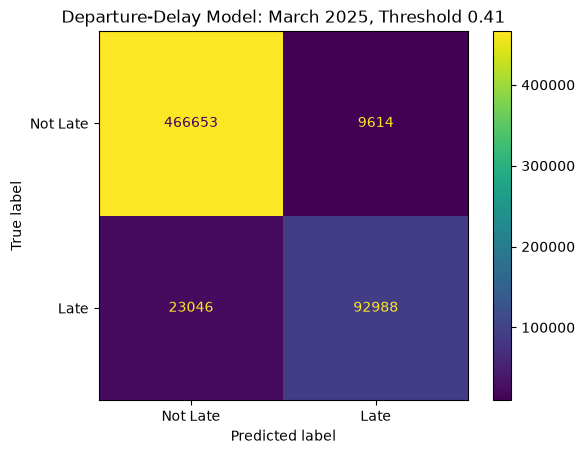

In [14]:
cm = confusion_matrix(y_test, test_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Late", "Late"]
)

disp.plot()
plt.title(f"Departure-Delay Model: March 2025, Threshold {best_threshold}")
plt.show()

In [15]:
scheduled_only_result = {
    "model": "Scheduled-only HGB",
    "train_month": "January",
    "validation_month": "February",
    "test_month": "March",
    "threshold": 0.10,
    "accuracy": 0.3345,
    "precision": 0.2040,
    "recall": 0.8258,
    "f1": 0.3271,
    "roc_auc": 0.5302
}

departure_delay_result = {
    "model": "Departure-delay HGB",
    "train_month": "January",
    "validation_month": "February",
    "test_month": "March",
    "threshold": best_threshold,
    "accuracy": accuracy_score(y_test, test_preds),
    "precision": precision_score(y_test, test_preds, zero_division=0),
    "recall": recall_score(y_test, test_preds, zero_division=0),
    "f1": f1_score(y_test, test_preds, zero_division=0),
    "roc_auc": roc_auc_score(y_test, test_probs)
}

comparison = pd.DataFrame([
    scheduled_only_result,
    departure_delay_result
])

comparison

,model,train_month,validation_month,test_month,threshold,accuracy,precision,recall,f1,roc_auc
0,Scheduled-only HGB,January,February,March,0.10,0.334500,0.204000,0.825800,0.327100,0.530200
1,Departure-delay HGB,January,February,March,0.41,0.944859,0.906298,0.801386,0.850619,0.962838


In [16]:
Path("../visuals").mkdir(exist_ok=True)

val_results_df.to_csv(
    "../visuals/departure_delay_threshold_results.csv",
    index=False
)

comparison.to_csv(
    "../visuals/scheduled_vs_departure_delay_comparison.csv",
    index=False
)

comparison

,model,train_month,validation_month,test_month,threshold,accuracy,precision,recall,f1,roc_auc
0,Scheduled-only HGB,January,February,March,0.10,0.334500,0.204000,0.825800,0.327100,0.530200
1,Departure-delay HGB,January,February,March,0.41,0.944859,0.906298,0.801386,0.850619,0.962838


The departure-delay model performed much better than the scheduled-only model. Using January for training, February for threshold selection, and March for final testing, the departure-delay model achieved an F1-score of about 0.85 and ROC-AUC of about 0.96.

This shows that actual departure information is highly predictive of arrival delay. The scheduled-only model attempted to predict delays before the flight departed and performed poorly on future-month data. The departure-delay model answers a different, near-real-time question: after a flight has departed, can we estimate whether it will arrive at least 15 minutes late?

The comparison highlights an important machine learning lesson: model performance depends heavily on what information is available at prediction time.